## Introduction

This notebook contains testing of best efficientnet model on unseen image samples.

## Setup

In [1]:
import io, os, boto3, torch, random
import pandas as pd
import torch.nn.functional as F
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
from IPython.display import display
from torchvision import transforms, models

BUCKET           = "skin-lesion-data-bucket"
CKPT_KEY         = "saved_models/efficientnet_b3_binary_finetuned_v2/efficientnet_b3_binary_finetuned_checkpoint_v2.pth"
IMAGE_PREFIX     = "new-unseen-images/images/"
GROUND_TRUTH_KEY = "new-unseen-images/labels/ISIC_2019_Test_GroundTruth.csv"
IMG_SIZE         = 300
CLASS_NAMES      = ["benign", "malignant"]

BENIGN_CLASSES    = ["NV", "BKL", "DF", "VASC"]
MALIGNANT_CLASSES = ["MEL", "BCC", "AK", "SCC"]

device = "cuda" if torch.cuda.is_available() else "cpu"
s3 = boto3.client("s3")
print("device:", device)

device: cuda


## Ground truth

In [2]:
obj = s3.get_object(Bucket=BUCKET, Key=GROUND_TRUTH_KEY)
gt = pd.read_csv(io.StringIO(obj["Body"].read().decode("utf-8")))

# one-hot -> subtype -> binary label. UNK is neither benign nor malignant, so drop it.
gt["subtype"] = gt[BENIGN_CLASSES + MALIGNANT_CLASSES + ["UNK"]].idxmax(axis=1)
gt = gt[gt["subtype"] != "UNK"].copy()
gt["true_label"] = gt["subtype"].isin(MALIGNANT_CLASSES).map({True: "malignant", False: "benign"})

print(f"{len(gt)} labelled images (UNK dropped)")
print(gt["true_label"].value_counts().to_string())
gt[["image", "subtype", "true_label"]].head()

6191 labelled images (UNK dropped)
true_label
benign       3350
malignant    2841


,image,subtype,true_label
0,ISIC_0034321,NV,benign
1,ISIC_0034322,NV,benign
2,ISIC_0034323,BCC,malignant
3,ISIC_0034324,NV,benign
4,ISIC_0034325,NV,benign


## Load model — run once

In [3]:
def load_model(bucket: str, model_s3_key: str, device: str = device):

    """Download + load the checkpoint once. Returns (model, threshold, n_out)."""
    cache = os.path.join("/tmp/model_cache", os.path.basename(model_s3_key))
    os.makedirs(os.path.dirname(cache), exist_ok=True)
    if not os.path.exists(cache):
        print("Downloading checkpoint…")
        s3.download_file(bucket, model_s3_key, cache)

    ckpt = torch.load(cache, map_location=device, weights_only=False)
    sd = {k.replace("module.", "", 1): v for k, v in ckpt["model_state_dict"].items()}

    threshold = float(ckpt["chosen_threshold"])
    n_out = sd[[k for k in sd if k.endswith("weight") and sd[k].dim() == 2][-1]].shape[0]

    model = models.efficientnet_b3(weights=None)
    model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, n_out)
    model.load_state_dict(sd)
    model.to(device).eval()

    f1 = ckpt.get("best_malignant_f1")
    print(f"Loaded · {n_out} logit(s) · threshold={threshold:.3f} · "
          f"val malignant F1={f1:.4f}" if f1 is not None else "")
    return model, threshold, n_out


MODEL, THRESHOLD, N_OUT = load_model(BUCKET, CKPT_KEY)

TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

Loaded · 2 logit(s) · threshold=0.431 · val malignant F1=0.8475


## Prediction pipeline

In [4]:
def fetch(bucket: str, key: str) -> Image.Image:
    raw = s3.get_object(Bucket=bucket, Key=key)["Body"].read()
    return Image.open(io.BytesIO(raw)).convert("RGB")


def score(tensors, model=None, n_out=None):
    """Batch of preprocessed tensors -> list of P(malignant)."""
    model = MODEL if model is None else model
    n_out = N_OUT if n_out is None else n_out
    x = torch.stack(tensors).to(device)
    with torch.inference_mode():
        logits = model(x)
        probs = (torch.sigmoid(logits)[:, 0] if n_out == 1
                 else F.softmax(logits, dim=1)[:, 1])
    return probs.float().cpu().tolist()


def predict_one(bucket: str, key: str, threshold: float = None,
                class_names=CLASS_NAMES, show: bool = True) -> dict:
    """Score a single S3 image. Uses its ARGUMENTS, not module globals."""
    threshold = THRESHOLD if threshold is None else threshold
    img = fetch(bucket, key)
    p = score([TF(img)])[0]
    label = class_names[1] if p >= threshold else class_names[0]

    result = {
        "image": os.path.splitext(os.path.basename(key))[0],
        "p_malignant": round(p, 6),
        "prediction": label,
        "margin": round(p - threshold, 6),
    }

    if show:
        print(f"{result['image']}   p={p:.4f}   thr={threshold:.3f}   -> {label.upper()}")
        display(img.resize((250, 250)))
    return result


def predict_many(bucket: str, keys, threshold: float = None,
                 class_names=CLASS_NAMES, batch_size: int = 16,
                 workers: int = 16, verbose: bool = True) -> pd.DataFrame:
    """Batched scoring — one forward pass per batch, not per image."""
    threshold = THRESHOLD if threshold is None else threshold
    keys = list(keys)
    rows = []

    with ThreadPoolExecutor(max_workers=workers) as pool:
        for i in range(0, len(keys), batch_size):
            chunk = keys[i:i + batch_size]
            tensors, ok = [], []
            for k, img in zip(chunk, pool.map(lambda kk: fetch(bucket, kk), chunk)):
                tensors.append(TF(img)); ok.append(k)
            for k, p in zip(ok, score(tensors)):
                rows.append({
                    "image": os.path.splitext(os.path.basename(k))[0],
                    "p_malignant": round(p, 6),
                    "prediction": class_names[1] if p >= threshold else class_names[0],
                    "margin": round(p - threshold, 6),
                })
            if verbose:
                print(f"  {min(i + batch_size, len(keys))}/{len(keys)}")

    return pd.DataFrame(rows)

## Sample 20 labelled images

In [5]:
random.seed(52)
sample = gt.sample(n=20, random_state=52).reset_index(drop=True)
sample[["image", "subtype", "true_label"]]

,image,subtype,true_label
0,ISIC_0064746,MEL,malignant
1,ISIC_0064061,NV,benign
2,ISIC_0063543,MEL,malignant
3,ISIC_0061210,BCC,malignant
4,ISIC_0034900,NV,benign
5,ISIC_0073226,BCC,malignant
6,ISIC_0057711,BCC,malignant
7,ISIC_0059475,BCC,malignant
8,ISIC_0060690,NV,benign
9,ISIC_0067541,BCC,malignant


## Predict

In [6]:
keys = [f"{IMAGE_PREFIX}{img}.jpg" for img in sample["image"]]

preds = predict_many(BUCKET, keys)
results = sample.merge(preds, on="image", how="left")
results = results[["image", "subtype", "true_label", "p_malignant", "prediction", "margin"]]
results["correct"] = results["true_label"] == results["prediction"]
results.sort_values("p_malignant", ascending=False)

  16/20
  20/20


,image,subtype,true_label,p_malignant,prediction,margin,correct
5,ISIC_0073226,BCC,malignant,0.969537,malignant,0.538985,True
3,ISIC_0061210,BCC,malignant,0.857814,malignant,0.427262,True
6,ISIC_0057711,BCC,malignant,0.847684,malignant,0.417132,True
13,ISIC_0067188,MEL,malignant,0.831707,malignant,0.401155,True
18,ISIC_0072026,NV,benign,0.800904,malignant,0.370352,False
11,ISIC_0062178,NV,benign,0.782197,malignant,0.351645,False
9,ISIC_0067541,BCC,malignant,0.772363,malignant,0.341811,True
0,ISIC_0064746,MEL,malignant,0.764505,malignant,0.333953,True
16,ISIC_0054017,BCC,malignant,0.745000,malignant,0.314448,True
2,ISIC_0063543,MEL,malignant,0.733482,malignant,0.302929,True


## Metrics

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

print(f"Accuracy: {results['correct'].mean():.3f}  ({results['correct'].sum()}/{len(results)})\n")
print(classification_report(results["true_label"], results["prediction"],
                            labels=CLASS_NAMES, digits=4, zero_division=0))
print("rows = true, cols = predicted, order:", CLASS_NAMES)
print(confusion_matrix(results["true_label"], results["prediction"], labels=CLASS_NAMES))

missed = results[~results["correct"]]
if len(missed):
    print(f"\n{len(missed)} misclassified:")
    print(missed[["image", "subtype", "true_label", "prediction", "p_malignant"]].to_string(index=False))

Accuracy: 0.850  (17/20)

              precision    recall  f1-score   support

      benign     1.0000    0.7273    0.8421        11
   malignant     0.7500    1.0000    0.8571         9

    accuracy                         0.8500        20
   macro avg     0.8750    0.8636    0.8496        20
weighted avg     0.8875    0.8500    0.8489        20

rows = true, cols = predicted, order: ['benign', 'malignant']
[[8 3]
 [0 9]]

3 misclassified:
       image subtype true_label prediction  p_malignant
ISIC_0064061      NV     benign  malignant     0.671938
ISIC_0062178      NV     benign  malignant     0.782197
ISIC_0072026      NV     benign  malignant     0.800904


## Visual check

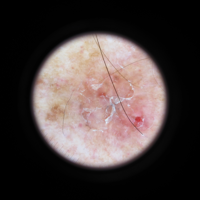

OK  ISIC_0073226  BCC   true=malignant pred=malignant p=0.9695

************************************************************



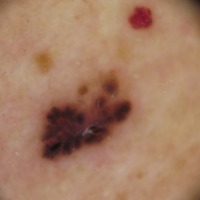

OK  ISIC_0061210  BCC   true=malignant pred=malignant p=0.8578

************************************************************



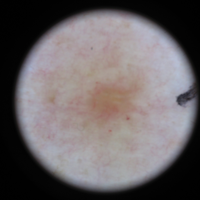

OK  ISIC_0057711  BCC   true=malignant pred=malignant p=0.8477

************************************************************



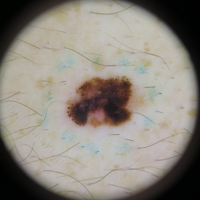

OK  ISIC_0067188  MEL   true=malignant pred=malignant p=0.8317

************************************************************



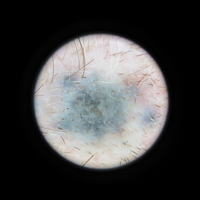

XX  ISIC_0072026  NV    true=benign    pred=malignant p=0.8009

************************************************************



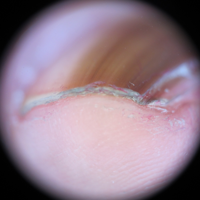

XX  ISIC_0062178  NV    true=benign    pred=malignant p=0.7822

************************************************************



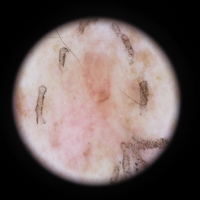

OK  ISIC_0067541  BCC   true=malignant pred=malignant p=0.7724

************************************************************



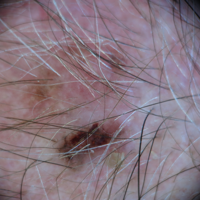

OK  ISIC_0064746  MEL   true=malignant pred=malignant p=0.7645

************************************************************



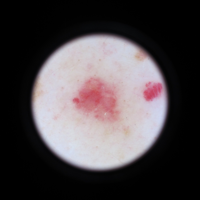

OK  ISIC_0054017  BCC   true=malignant pred=malignant p=0.7450

************************************************************



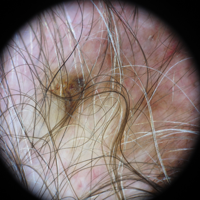

OK  ISIC_0063543  MEL   true=malignant pred=malignant p=0.7335

************************************************************



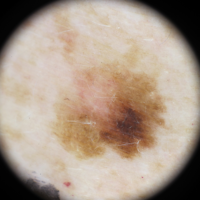

XX  ISIC_0064061  NV    true=benign    pred=malignant p=0.6719

************************************************************



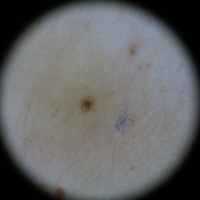

OK  ISIC_0059475  BCC   true=malignant pred=malignant p=0.6074

************************************************************



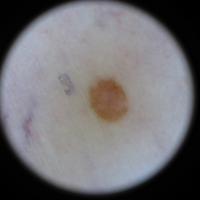

OK  ISIC_0060690  NV    true=benign    pred=benign    p=0.2194

************************************************************



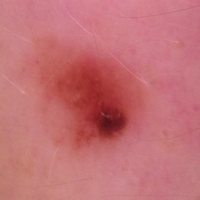

OK  ISIC_0034556  NV    true=benign    pred=benign    p=0.2051

************************************************************



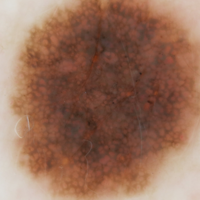

OK  ISIC_0073162  NV    true=benign    pred=benign    p=0.1841

************************************************************



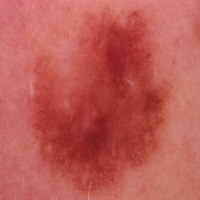

OK  ISIC_0034900  NV    true=benign    pred=benign    p=0.1640

************************************************************



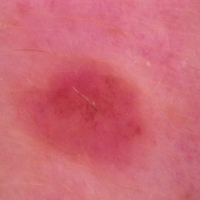

OK  ISIC_0035411  NV    true=benign    pred=benign    p=0.1463

************************************************************



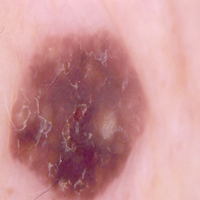

OK  ISIC_0034360  BKL   true=benign    pred=benign    p=0.1431

************************************************************



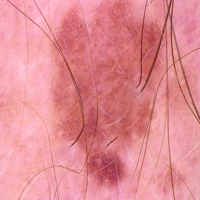

OK  ISIC_0034445  NV    true=benign    pred=benign    p=0.1035

************************************************************



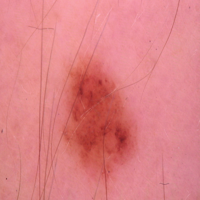

OK  ISIC_0035161  NV    true=benign    pred=benign    p=0.0924

************************************************************



In [8]:
for _, r in results.sort_values("p_malignant", ascending=False).iterrows():
    mark = "OK " if r["correct"] else "XX "
    display(fetch(BUCKET, f"{IMAGE_PREFIX}{r['image']}.jpg").resize((200, 200)))
    print(f"{mark} {r['image']}  {r['subtype']:<5} true={r['true_label']:<9} "
          f"pred={r['prediction']:<9} p={r['p_malignant']:.4f}")

    print()
    print("*"*60)
    print()